## 1. Build “dependence factors” for the US and China

Instead of treating each market separately, construct **latent factors** that summarize each region.

Let

* (R_{i,t}) = return of market (i) at time (t)

Create:

$$
F^{US}_t = \text{first PCA component of major US assets}
$$

$$
F^{CN}_t = \text{first PCA component of Chinese assets}
$$

Example universes:

**US**

* SPX / ES
* Nasdaq
* US credit spreads
* DXY
* Treasury yields

**China**

* CSI 300
* CNH/CNY
* Chinese credit
* Iron ore / copper (China demand proxies)
* Hang Seng

These factors represent **global US-risk and China-risk shocks**.

---

## 2. Measure market exposure to each factor

For each global asset (i):

$$
R_{i,t} = \beta_i^{US} F^{US}_t + \beta_i^{CN} F^{CN}*t + \epsilon*{i,t}
$$

Now every market has two interpretable numbers:

* **US sensitivity**
* **China sensitivity**

This gives a **map of global dependence**.

Example interpretation:

| Market      | β_US   | β_CN | Interpretation     |
| ----------- | ------ | ---- | ------------------ |
| Korea       | high   | high | bridge market      |
| Australia   | medium | high | China demand proxy |
| Europe      | high   | low  | US-driven          |
| Commodities | low    | high | China growth       |

---

## 3. Detect lead–lag structure

To detect **who moves first**, compute **lagged regressions**.

$$
R_{i,t} = \sum_{k=0}^{K} \alpha_k F_{t-k}^{US}
$$

and

$$
R_{i,t} = \sum_{k=0}^{K} \gamma_k F_{t-k}^{CN}
$$

Interpretation:

* large (k=0) → **synchronous**
* large (k=1) or (k=2) → **lagging response**

This reveals things like:

* commodities lag China by ~1–2 days
* Europe reacts to US overnight
* EM FX responds to US rates first

---

## 4. Cross-correlation heatmap

A fast diagnostic is the **max cross-correlation over lags**:

$$
\rho_i(\tau) = corr(R_{i,t}, F_{t-\tau})
$$

Then record

$$
\tau^* = \arg\max_\tau |\rho_i(\tau)|
$$

Plot:

| Asset  | Max Corr | Lag       |
| ------ | -------- | --------- |
| Copper | 0.65     | CN +1 day |
| AUD    | 0.60     | CN +1 day |
| Europe | 0.55     | US +1 day |

This directly identifies **lead markets**.

---

## 5. Network view (very powerful)

Construct a **directed network** using Granger causality or lagged correlations.

Nodes = markets
Edge weight = predictive strength

Then compute:

* **centrality**
* **information flow**

You often see:

```
US → Europe → EM
China → commodities → FX
```

---

## 6. Regime dependence (important)

Lead–lag relationships change in different regimes.

Split data by:

* risk-on vs risk-off
* high vs low volatility
* USD strength regimes

Then recompute the factor exposures.

Example:

During crises

* US dominates everything

During commodity cycles

* China dominates EM and materials

---

## 7. A simple empirical test

You can test predictability directly:

$$
R_{i,t+1} = \beta_1 F^{US}_t + \beta_2 F^{CN}_t
$$

Significant coefficients indicate **true lead information**.

---

## 8. Visualization that works well

Three plots are very useful:

1. **Factor loadings scatter**

   * x = US beta
   * y = China beta

2. **Lag heatmap**

   * asset vs lag

3. **Information network graph**

These give intuition extremely quickly.

---

## Why this approach works

It avoids two major problems:

**1. Pairwise correlation explosion**

Hundreds of assets → thousands of correlations.

Factor model compresses this to **two interpretable drivers**.

**2. Spurious lead–lag**

Lag regressions against **factors** are much more stable than asset-asset comparisons.

---

## If you want something *very powerful*

Combine:

**Rolling PCA + lead–lag regressions**

to measure **time-varying dependence on US vs China shocks**.

That lets you detect:

* when China becomes the marginal global driver
* when US liquidity dominates markets.


In [8]:
# ============================================================
# Global Markets Dependence Study
# US vs China dependence + lead/lag analysis
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm


# ============================================================
# Settings
# ============================================================

START = "2014-01-01"
END = None

MAX_LAG = 5              # test lags from -MAX_LAG to +MAX_LAG
ROLLING_WINDOW = 126     # ~6 months
MIN_OBS = 60

# Universe used to construct latent regional factors
US_TICKERS = {
    "SPY": "SPY",          # US equities
    "QQQ": "QQQ",          # US tech
    "IWM": "IWM",          # US small cap
    "TLT": "TLT",          # long bonds
    "LQD": "LQD",          # investment grade credit
    "HYG": "HYG",          # high yield
    "UUP": "UUP",          # dollar
}

CHINA_TICKERS = {
    "FXI": "FXI",          # large-cap China
    "MCHI": "MCHI",        # broader China
    "KWEB": "KWEB",        # China internet
    "ASHR": "ASHR",        # A-shares
    "CNH": "CYB",          # rough China rates proxy / not FX, but a stabilizer if CNH unavailable
    "EWH": "EWH",          # Hong Kong
    "COPX": "COPX",        # industrial metals / China-linked demand proxy
}

# Assets to study dependence for
STUDY_TICKERS = {
    "US_Equity": "SPY",
    "Europe": "VGK",
    "Japan": "EWJ",
    "India": "INDA",
    "Korea": "EWY",
    "Taiwan": "EWT",
    "Australia": "EWA",
    "Brazil": "EWZ",
    "Mexico": "EWW",
    "EM": "EEM",
    "Copper": "CPER",
    "Gold": "GLD",
    "Oil": "USO",
    "Bitcoin": "IBIT",
    "Semis": "SOXX",
    "Miners": "COPX",
    "US_HY": "HYG",
    "US_Bonds": "TLT",
    "Dollar": "UUP",
}

# Optional: if some tickers fail, the script will continue with the ones that work.


# ============================================================
# Helpers
# ============================================================

def download_prices(ticker_map, start=START, end=END):
    """
    Download adjusted close prices for a dict {label: ticker}.
    Returns price DataFrame with columns as labels.
    """
    raw = yf.download(
        list(ticker_map.values()),
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
        group_by="ticker",
        threads=True,
    )

    out = pd.DataFrame()

    for label, ticker in ticker_map.items():
        try:
            if isinstance(raw.columns, pd.MultiIndex):
                series = raw[ticker]["Close"].rename(label)
            else:
                # single ticker case
                series = raw["Close"].rename(label)
            out[label] = series
        except Exception:
            print(f"Warning: failed to extract {label} ({ticker})")

    out = out.sort_index()
    out = out.dropna(how="all")
    return out


def compute_returns(prices):
    """
    Log returns.
    """
    rets = np.log(prices / prices.shift(1))
    return rets.dropna(how="all")


def first_pca_factor(returns_df, name):
    """
    Standardize series cross-sectionally and extract first PCA factor.
    Returns factor series and loadings.
    """
    df = returns_df.dropna(axis=1, how="any").dropna(axis=0, how="any")
    if df.shape[1] < 2:
        raise ValueError(f"Need at least 2 valid series for factor {name}")

    scaler = StandardScaler()
    X = scaler.fit_transform(df.values)

    pca = PCA(n_components=1)
    factor = pca.fit_transform(X).flatten()

    factor_s = pd.Series(factor, index=df.index, name=name)
    loadings = pd.Series(pca.components_[0], index=df.columns, name=f"{name}_loading")

    # Orient factor so it is positively aligned with the average return
    avg_proj = np.corrcoef(factor_s.values, df.mean(axis=1).values)[0, 1]
    if avg_proj < 0:
        factor_s *= -1
        loadings *= -1

    return factor_s, loadings


def align_data(*series_or_frames):
    """
    Inner join on date index across many series/dataframes.
    """
    out = pd.concat(series_or_frames, axis=1, join="inner")
    return out.dropna()


def exposure_regression(asset_ret, us_factor, cn_factor):
    """
    Estimate asset dependence on US and China factors:
    r_t = alpha + b_us * F_us + b_cn * F_cn + e_t
    """
    df = align_data(asset_ret.rename("asset"), us_factor.rename("us"), cn_factor.rename("cn"))
    if len(df) < 30:
        return np.nan, np.nan, np.nan, np.nan

    X = sm.add_constant(df[["us", "cn"]])
    y = df["asset"]
    model = sm.OLS(y, X).fit()

    return (
        model.params.get("us", np.nan),
        model.params.get("cn", np.nan),
        model.rsquared,
        model.pvalues.get("us", np.nan),
    )


def lagged_corr(x, y, lags):
    """
    corr(x_t, y_{t-lag})
    Positive lag => y leads x
    Negative lag => x leads y
    """
    vals = []
    for lag in lags:
        if lag > 0:
            a = x.copy()
            b = y.shift(lag)
        elif lag < 0:
            a = x.shift(-lag)
            b = y.copy()
        else:
            a = x.copy()
            b = y.copy()

        df = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
        if len(df) < 20:
            vals.append(np.nan)
        else:
            vals.append(df["a"].corr(df["b"]))
    return pd.Series(vals, index=lags)


def best_lag(x, y, max_lag=MAX_LAG):
    lags = list(range(-max_lag, max_lag + 1))
    lc = lagged_corr(x, y, lags)
    if lc.dropna().empty:
        return np.nan, np.nan, lc
    idx = lc.abs().idxmax()
    return idx, lc.loc[idx], lc


def rolling_relative_dependence(asset_ret, us_factor, cn_factor, window=ROLLING_WINDOW):
    """
    Rolling difference in explanatory power / beta balance:
    beta_us - beta_cn over time
    """
    df = align_data(asset_ret.rename("asset"), us_factor.rename("us"), cn_factor.rename("cn"))
    out = []

    for i in range(window, len(df) + 1):
        sub = df.iloc[i - window:i]
        X = sm.add_constant(sub[["us", "cn"]])
        y = sub["asset"]
        try:
            model = sm.OLS(y, X).fit()
            out.append({
                "date": sub.index[-1],
                "beta_us": model.params.get("us", np.nan),
                "beta_cn": model.params.get("cn", np.nan),
                "rsq": model.rsquared,
                "relative_us_minus_cn": model.params.get("us", 0.0) - model.params.get("cn", 0.0),
            })
        except Exception:
            pass

    if not out:
        return pd.DataFrame()

    out = pd.DataFrame(out).set_index("date")
    return out


In [9]:


# ============================================================
# Download data
# ============================================================

print("Downloading US factor universe...")
us_prices = download_prices(US_TICKERS)

print("Downloading China factor universe...")
cn_prices = download_prices(CHINA_TICKERS)

print("Downloading study assets...")
study_prices = download_prices(STUDY_TICKERS)

# Returns
us_rets = compute_returns(us_prices)
cn_rets = compute_returns(cn_prices)
study_rets = compute_returns(study_prices)

# Keep sufficiently populated columns
us_rets = us_rets.loc[:, us_rets.notna().sum() > MIN_OBS]
cn_rets = cn_rets.loc[:, cn_rets.notna().sum() > MIN_OBS]
study_rets = study_rets.loc[:, study_rets.notna().sum() > MIN_OBS]

print("\nUS series used:", list(us_rets.columns))
print("China series used:", list(cn_rets.columns))
print("Study assets used:", list(study_rets.columns))




US series used: ['SPY', 'QQQ', 'IWM', 'TLT', 'LQD', 'HYG', 'UUP']
China series used: ['FXI', 'MCHI', 'KWEB', 'ASHR', 'CNH', 'EWH', 'COPX']
Study assets used: ['US_Equity', 'Europe', 'Japan', 'India', 'Korea', 'Taiwan', 'Australia', 'Brazil', 'Mexico', 'EM', 'Copper', 'Gold', 'Oil', 'Bitcoin', 'Semis', 'Miners', 'US_HY', 'US_Bonds', 'Dollar']


In [10]:

# ============================================================
# Build latent factors
# ============================================================

us_factor, us_loadings = first_pca_factor(us_rets, "US_Factor")
cn_factor, cn_loadings = first_pca_factor(cn_rets, "China_Factor")

factor_df = align_data(us_factor, cn_factor)
us_factor = factor_df["US_Factor"]
cn_factor = factor_df["China_Factor"]

us_factor = us_factor * us_rets.std().mean()
cn_factor = cn_factor * cn_rets.std().mean()
# ============================================================
# Estimate exposures
# ============================================================

rows = []
for asset in study_rets.columns:
    b_us, b_cn, rsq, p_us = exposure_regression(study_rets[asset], us_factor, cn_factor)
    rows.append({
        "asset": asset,
        "beta_us": b_us,
        "beta_cn": b_cn,
        "rsq": rsq,
        "pval_us": p_us,
    })

exposures = pd.DataFrame(rows).set_index("asset").sort_values(["beta_us", "beta_cn"], ascending=False)

print("\n=== Exposure Table ===")
print(exposures.round(4))



=== Exposure Table ===
           beta_us  beta_cn     rsq  pval_us
asset                                       
Bitcoin     0.9116   0.0412  0.1878   0.0000
Semis       0.8593   0.0699  0.6636   0.0000
US_Equity   0.6107   0.0074  0.9095   0.0000
Australia   0.5448   0.1003  0.6697   0.0000
Brazil      0.5317   0.1619  0.3542   0.0000
Europe      0.4763   0.0772  0.7098   0.0000
Mexico      0.4497   0.1044  0.4331   0.0000
Korea       0.4222   0.1690  0.5615   0.0000
Miners      0.4183   0.3228  0.5423   0.0000
India       0.3948   0.0843  0.4224   0.0000
Japan       0.3929   0.0625  0.5472   0.0000
Taiwan      0.3788   0.1388  0.5898   0.0000
Oil         0.2927   0.0940  0.0920   0.0000
EM          0.2760   0.2394  0.8491   0.0000
US_HY       0.2754  -0.0067  0.7810   0.0000
Copper      0.1104   0.1560  0.1069   0.0000
US_Bonds    0.0414  -0.0492  0.0232   0.0008
Gold        0.0324   0.0296  0.0212   0.0135
Dollar     -0.0332  -0.0127  0.0393   0.0000


In [11]:


# ============================================================
# Lead/Lag analysis
# Positive lag => factor leads asset
# ============================================================

lag_rows = []
lag_grid_us = {}
lag_grid_cn = {}

for asset in study_rets.columns:
    asset_series = study_rets[asset]

    lag_us, corr_us, lc_us = best_lag(asset_series, us_factor, max_lag=MAX_LAG)
    lag_cn, corr_cn, lc_cn = best_lag(asset_series, cn_factor, max_lag=MAX_LAG)

    lag_rows.append({
        "asset": asset,
        "best_lag_us": lag_us,
        "best_corr_us": corr_us,
        "best_lag_cn": lag_cn,
        "best_corr_cn": corr_cn,
    })

    lag_grid_us[asset] = lc_us
    lag_grid_cn[asset] = lc_cn

lag_summary = pd.DataFrame(lag_rows).set_index("asset")

print("\n=== Lead/Lag Summary ===")
print(lag_summary.round(4))




=== Lead/Lag Summary ===
           best_lag_us  best_corr_us  best_lag_cn  best_corr_cn
asset                                                          
US_Equity            0        0.9535            0        0.5908
Europe               0        0.8223            0        0.6427
Japan                0        0.7225            0        0.5627
India                0        0.6261            0        0.5171
Korea                0        0.6856            0        0.6551
Taiwan               0        0.7092            0        0.6631
Australia            0        0.7944            0        0.6364
Brazil               0        0.5592            0        0.5002
Mexico               0        0.6308            0        0.5305
EM                   0        0.7593            0        0.8746
Copper               0        0.2499            0        0.3190
Gold                 0        0.1189            0        0.1386
Oil                  0        0.2836            0        0.2570
Bitcoin       

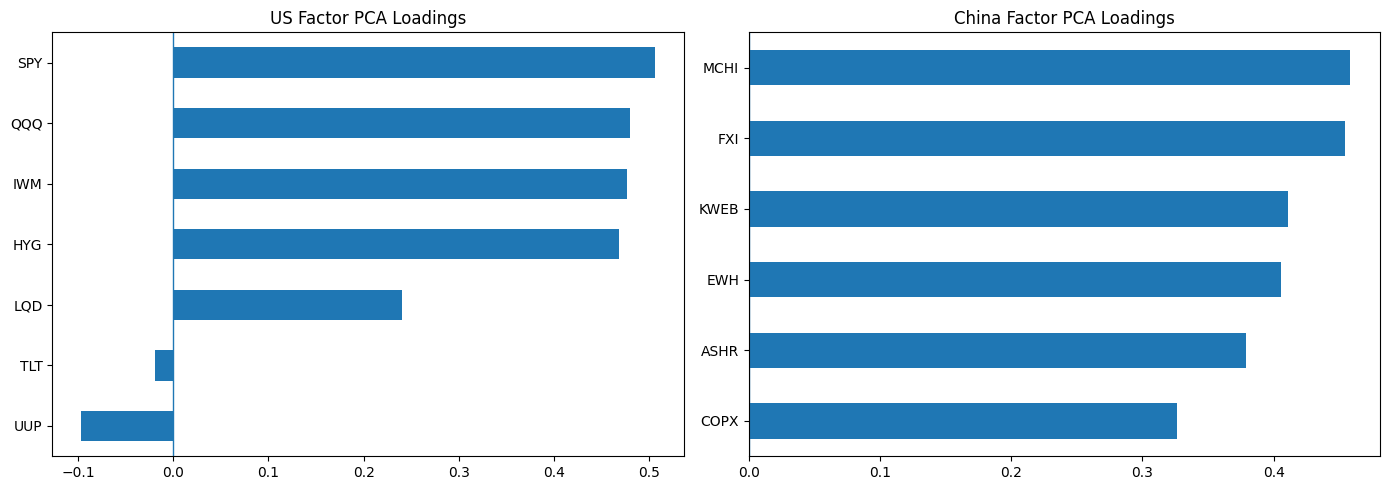

In [12]:

# ============================================================
# Plot 1: Factor loadings used to construct regional factors
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

us_loadings.sort_values().plot(kind="barh", ax=axes[0], title="US Factor PCA Loadings")
axes[0].axvline(0, linewidth=1)

cn_loadings.sort_values().plot(kind="barh", ax=axes[1], title="China Factor PCA Loadings")
axes[1].axvline(0, linewidth=1)

plt.tight_layout()
plt.show()


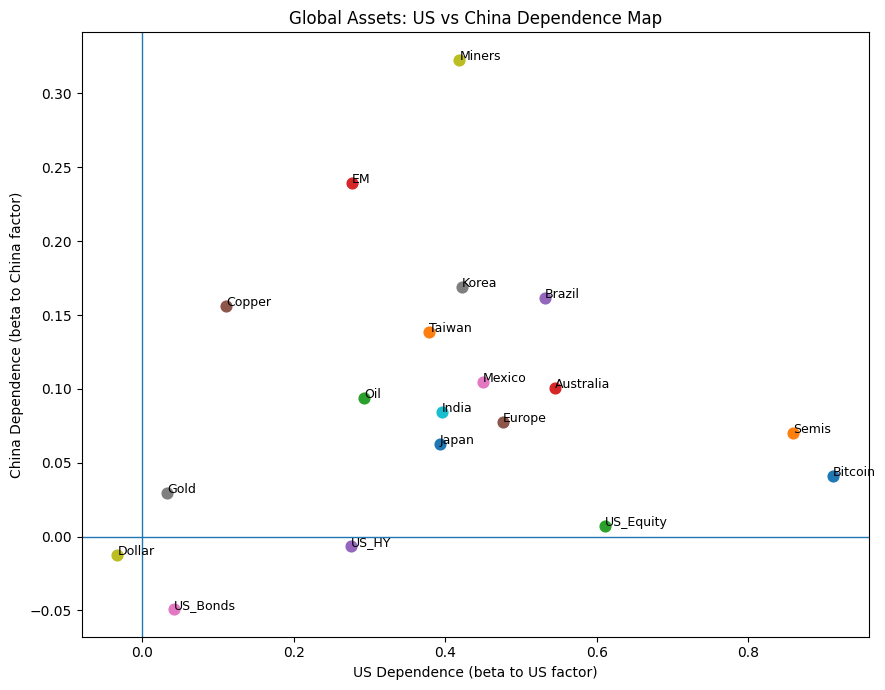

In [13]:


# ============================================================
# Plot 2: Scatter of dependence on US vs China
# ============================================================

plt.figure(figsize=(9, 7))
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

for asset, row in exposures.iterrows():
    x = row["beta_us"]
    y = row["beta_cn"]
    plt.scatter(x, y, s=60)
    plt.text(x, y, asset, fontsize=9)

plt.xlabel("US Dependence (beta to US factor)")
plt.ylabel("China Dependence (beta to China factor)")
plt.title("Global Assets: US vs China Dependence Map")
plt.tight_layout()
plt.show()



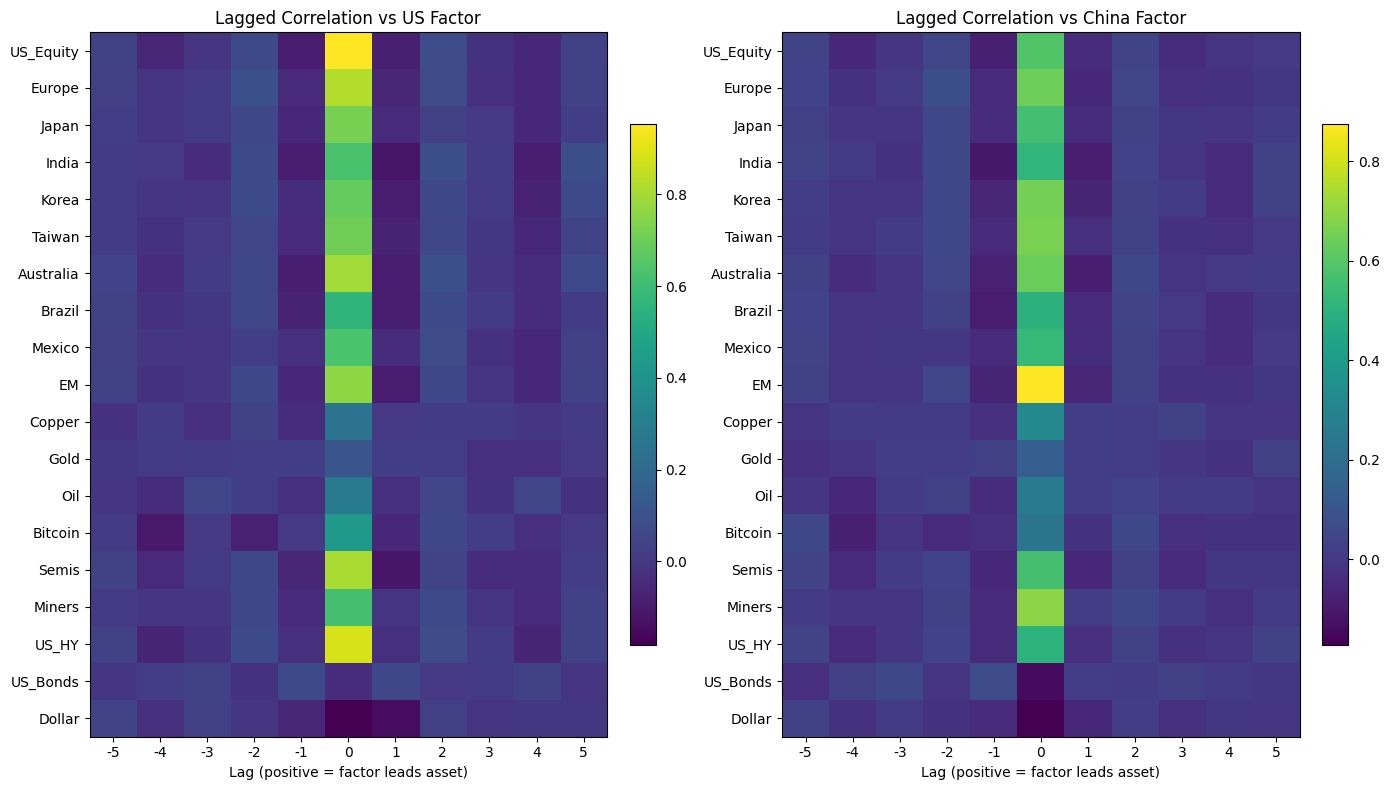


=== Next-Day Predictive Regression Summary ===
           coef_us_t  coef_cn_t  tstat_us  tstat_cn     rsq
asset                                                      
Dollar       -0.0474     0.0064   -7.8771    2.1954  0.0231
India        -0.0816    -0.0115   -4.5388   -1.3244  0.0150
Semis        -0.1494     0.0145   -5.6621    1.1442  0.0130
Australia    -0.0565    -0.0186   -2.9658   -2.0306  0.0103
EM           -0.0690    -0.0023   -4.0264   -0.2747  0.0090
Korea        -0.0766    -0.0056   -3.6679   -0.5560  0.0083
Brazil       -0.1270     0.0091   -4.2802    0.6359  0.0079
US_Equity    -0.0602     0.0051   -4.0956    0.7267  0.0070
Taiwan       -0.0633     0.0081   -3.5905    0.9566  0.0049
Europe       -0.0294    -0.0105   -1.8651   -1.3799  0.0043
US_Bonds      0.0431    -0.0080    3.4553   -1.3261  0.0042
Bitcoin      -0.1304     0.0074   -1.2214    0.1733  0.0031
Oil          -0.0821     0.0385   -2.5048    2.4411  0.0025
Japan        -0.0248    -0.0040   -1.6767   -0.5621 

In [15]:

# ============================================================
# Plot 3: Lead/Lag heatmaps
# ============================================================

lag_order = list(range(-MAX_LAG, MAX_LAG + 1))
lag_heat_us = pd.DataFrame(lag_grid_us).T[lag_order]
lag_heat_cn = pd.DataFrame(lag_grid_cn).T[lag_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

im1 = axes[0].imshow(lag_heat_us.values, aspect="auto")
axes[0].set_title("Lagged Correlation vs US Factor")
axes[0].set_xticks(range(len(lag_order)))
axes[0].set_xticklabels(lag_order)
axes[0].set_yticks(range(len(lag_heat_us.index)))
axes[0].set_yticklabels(lag_heat_us.index)
axes[0].set_xlabel("Lag (positive = factor leads asset)")
plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(lag_heat_cn.values, aspect="auto")
axes[1].set_title("Lagged Correlation vs China Factor")
axes[1].set_xticks(range(len(lag_order)))
axes[1].set_xticklabels(lag_order)
axes[1].set_yticks(range(len(lag_heat_cn.index)))
axes[1].set_yticklabels(lag_heat_cn.index)
axes[1].set_xlabel("Lag (positive = factor leads asset)")
plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ============================================================
# Optional: next-day predictive regression
# asset_{t+1} ~ US_t + China_t
# ============================================================

predict_rows = []
for asset in study_rets.columns:
    df = align_data(
        study_rets[asset].shift(-1).rename("asset_fwd"),
        us_factor.rename("us"),
        cn_factor.rename("cn")
    )
    if len(df) < 50:
        continue

    X = sm.add_constant(df[["us", "cn"]])
    y = df["asset_fwd"]
    model = sm.OLS(y, X).fit()

    predict_rows.append({
        "asset": asset,
        "coef_us_t": model.params.get("us", np.nan),
        "coef_cn_t": model.params.get("cn", np.nan),
        "tstat_us": model.tvalues.get("us", np.nan),
        "tstat_cn": model.tvalues.get("cn", np.nan),
        "rsq": model.rsquared,
    })

predictive = pd.DataFrame(predict_rows).set_index("asset").sort_values("rsq", ascending=False)

print("\n=== Next-Day Predictive Regression Summary ===")
print(predictive.round(4))

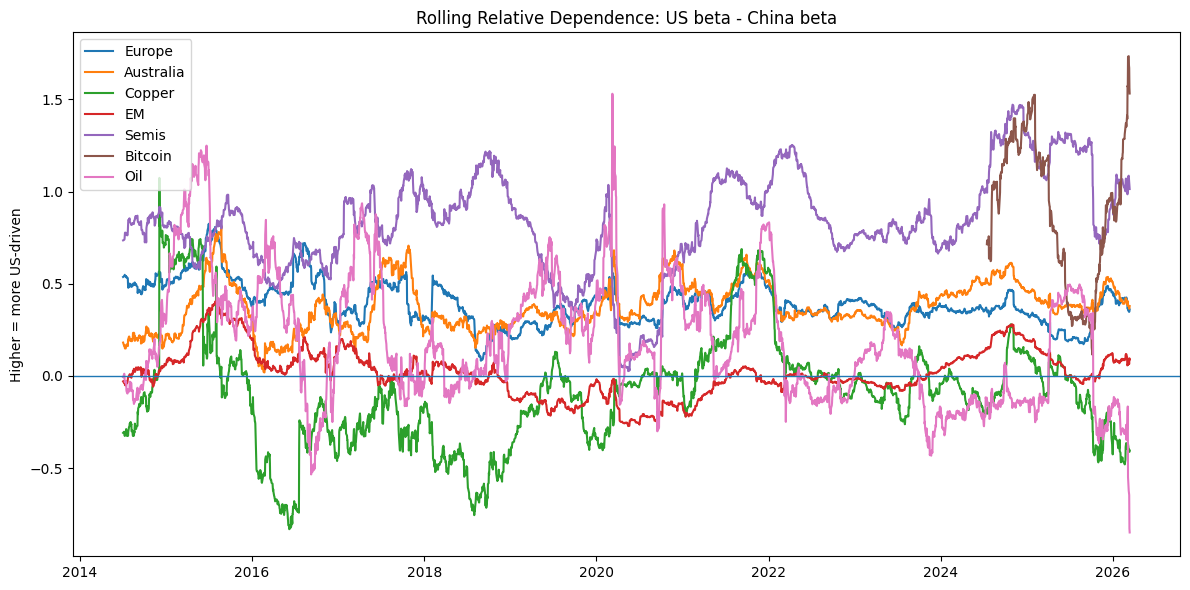

In [16]:

# ============================================================
# Plot 4: Rolling relative dependence for selected assets
# ============================================================

selected_assets = [a for a in ["Europe", "Australia", "Copper", "EM", "Semis", "Bitcoin", "Oil"] if a in study_rets.columns]

plt.figure(figsize=(12, 6))
for asset in selected_assets:
    roll = rolling_relative_dependence(study_rets[asset], us_factor, cn_factor, window=ROLLING_WINDOW)
    if not roll.empty:
        plt.plot(roll.index, roll["relative_us_minus_cn"], label=asset)

plt.axhline(0, linewidth=1)
plt.title("Rolling Relative Dependence: US beta - China beta")
plt.ylabel("Higher = more US-driven")
plt.legend()
plt.tight_layout()
plt.show()

